In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import detrend
from statsmodels.tsa.seasonal import seasonal_decompose, STL

from scipy.fft import fft, fftfreq
import pywt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('retail_sales_mock_data.csv')

In [3]:
df.head(5)

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          48 non-null     object
 1   SalesAmount   48 non-null     int64 
 2   Promotion     48 non-null     int64 
 3   HolidayMonth  48 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.6+ KB


In [49]:
# пропусков нет

# Разведочный анализ данных (EDA)

Провести предварительный анализ временного ряда, визуализации различных типов.

In [7]:
# Преобразуем дату
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

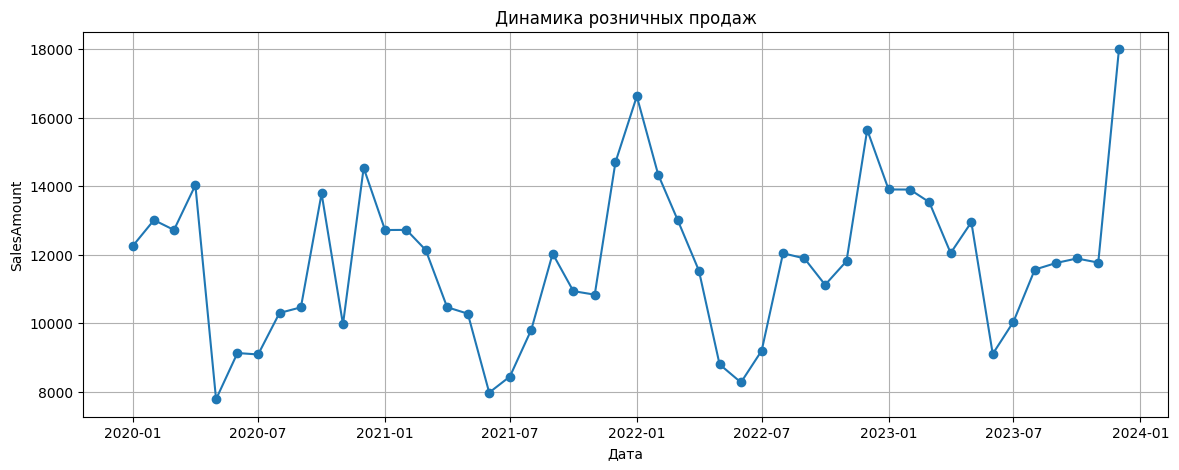

In [23]:
plt.figure(figsize=(14,5))
plt.plot(df['SalesAmount'], marker='o')
plt.title("Динамика розничных продаж")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.grid(True)
plt.show()

In [ ]:
# Каждый год есть заметные всплески продаж на новогодние праздники и сильный спад к середине лета. Прослеживается явная периодичность. Возможен небольшой восходящий тренд

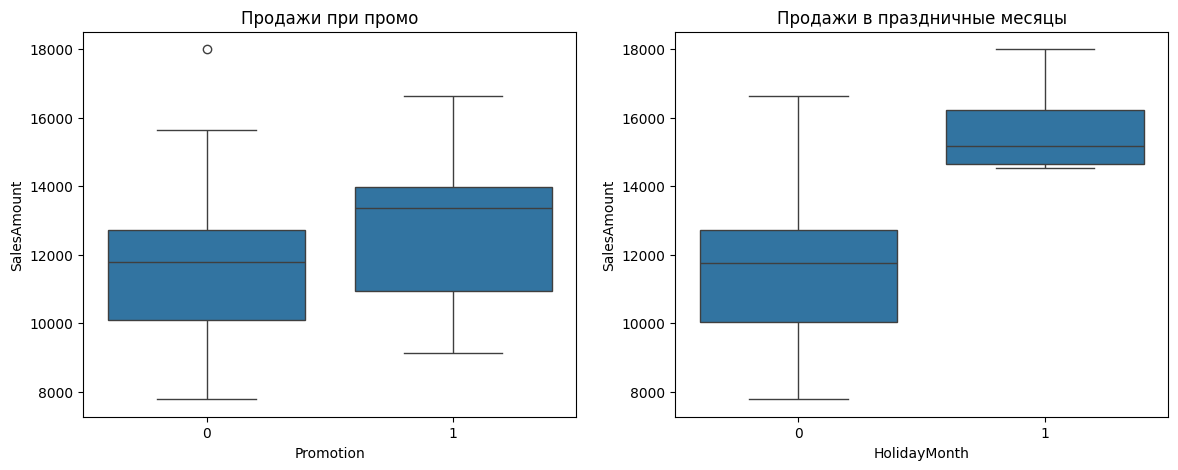

In [24]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(x='Promotion', y='SalesAmount', data=df, ax=axes[0])
axes[0].set_title("Продажи при промо")

sns.boxplot(x='HolidayMonth', y='SalesAmount', data=df, ax=axes[1])
axes[1].set_title("Продажи в праздничные месяцы")

plt.show()

In [ ]:
# Продажи в праздники сильно выше и стабильнее, чем в не праздничные дни.
# Акции тоже увеличивают количество продаж, но, возможно, большаяя часть акций в праздничные дни

In [ ]:
len(df.query('Promotion == 1 and HolidayMonth == 1'))

0

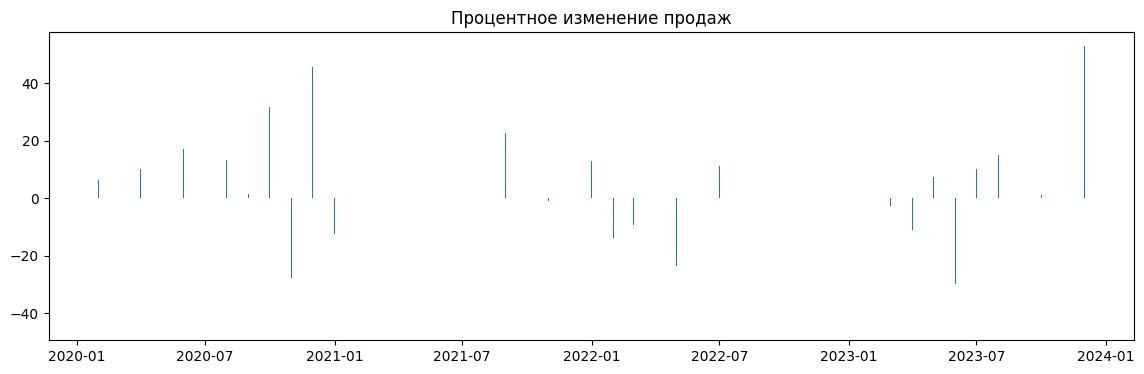

In [38]:
df['pct_change'] = df['SalesAmount'].pct_change() * 100

plt.figure(figsize=(14,4))
plt.bar(df.index, df['pct_change'])
plt.title("Процентное изменение продаж")
plt.show()

Выполнить декомпозицию ряда на компоненты тремя методами:
- классическая аддитивная/мультипликативная/stl декомпозиция (например, seasonal_decompose из statsmodels);
- спектральный анализ с применением быстрого преобразования Фурье (FFT);
- вейвлет-анализ (например, с использованием вейвлета Морле или Добеши).


In [39]:
period = 12

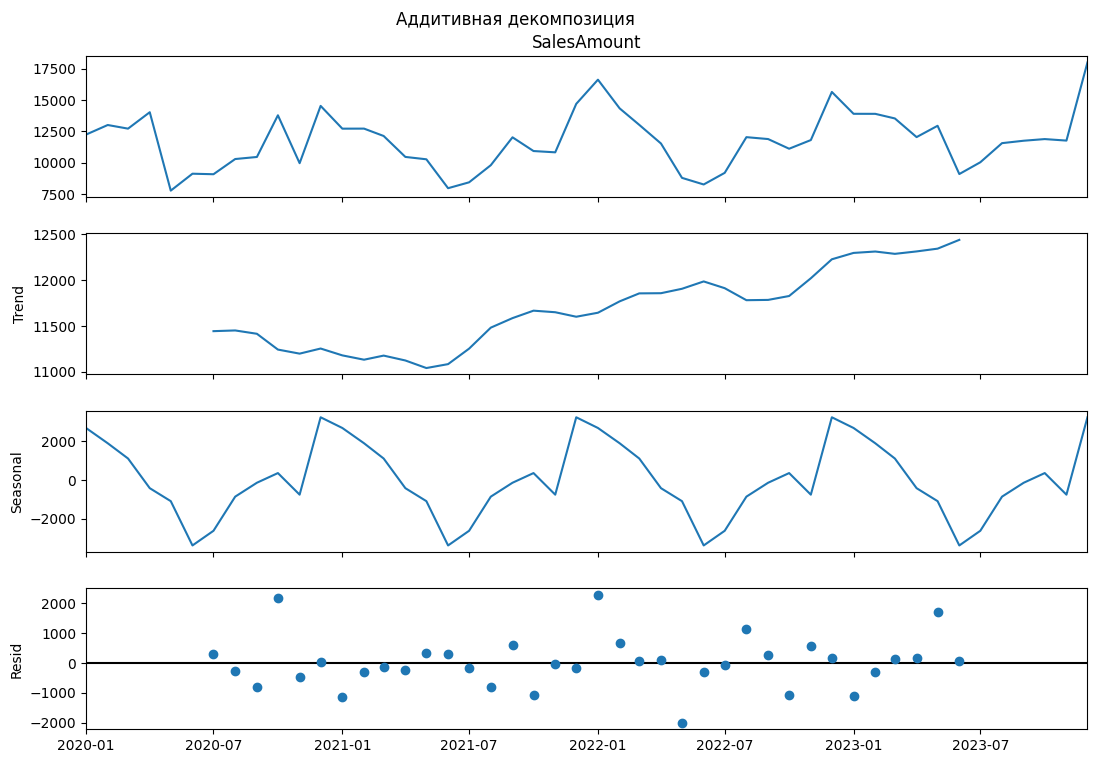

In [40]:
result_add = seasonal_decompose(df['SalesAmount'],
                                model='additive',
                                period=12)

fig = result_add.plot()
fig.set_size_inches(12,8)
plt.suptitle("Аддитивная декомпозиция")
plt.show()

In [ ]:
# Видна выраженная сезонность.
# Умеренный восходящий тренд.
# Амплитуда колебаний примерно одинаковая на всем промежутке
# аддитивная модель подходит

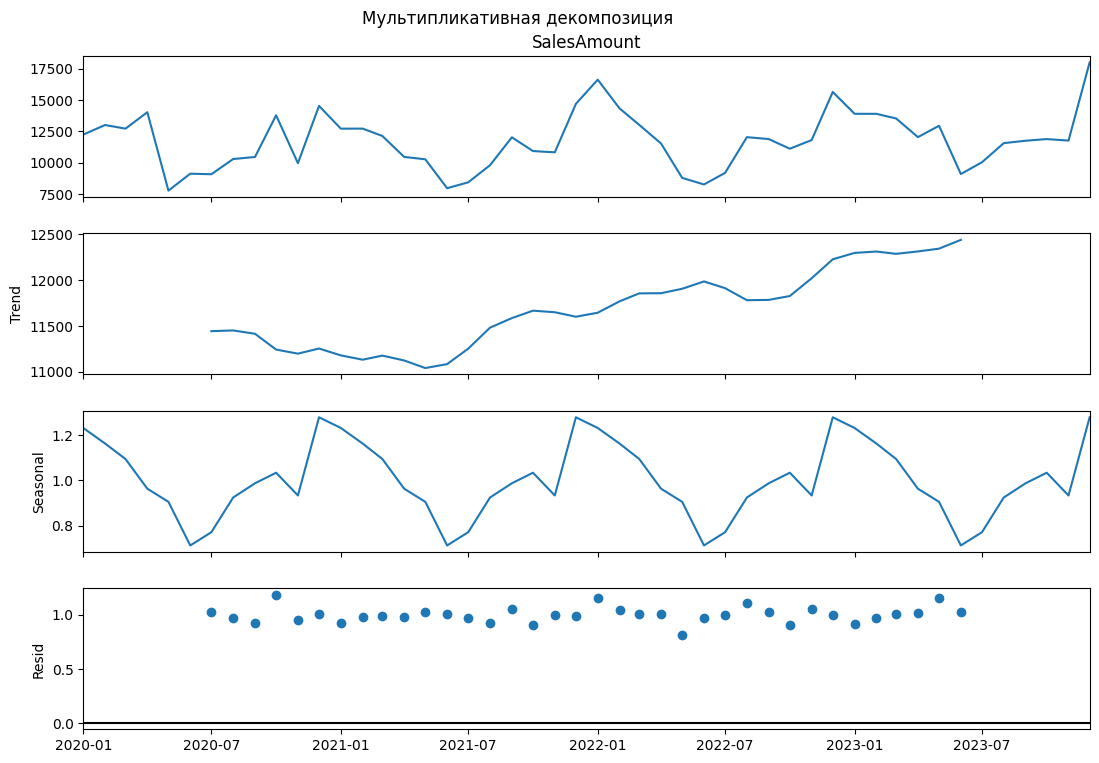

In [41]:
result_mul = seasonal_decompose(df['SalesAmount'],
                                model='multiplicative',
                                period=12)

fig = result_mul.plot()
fig.set_size_inches(12,8)
plt.suptitle("Мультипликативная декомпозиция")
plt.show()

In [ ]:
# Мультипликативная декомпозиция также выявила устойчивый восходящий тренд и выраженную годовую сезонность
# Мультипликативная модель корректно описывает структуру данных, но аддитивная декомпозиция является более интерпретируемой

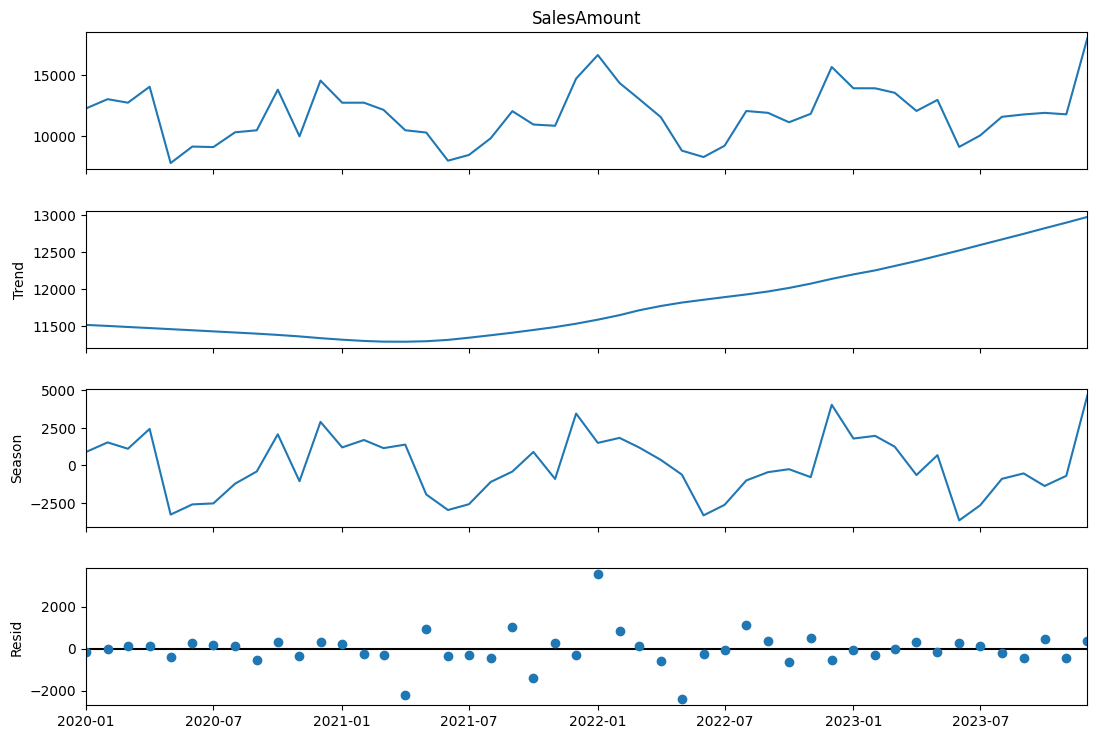

In [42]:
stl = STL(df['SalesAmount'],
          period=12,
          seasonal=13,
          robust=True)

result_stl = stl.fit()

fig = result_stl.plot()
fig.set_size_inches(12,8)
plt.show()

In [43]:
# SLT разложение выявило аналогичные зависимости

In [ ]:
# Необходим убрать тренд, тк с ним плохо работает FFT

sales_detrended = detrend(df['SalesAmount'].values)

n = len(sales_detrended)
fft_vals = fft(sales_detrended)
freqs = fftfreq(n, d=1)

power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]

periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

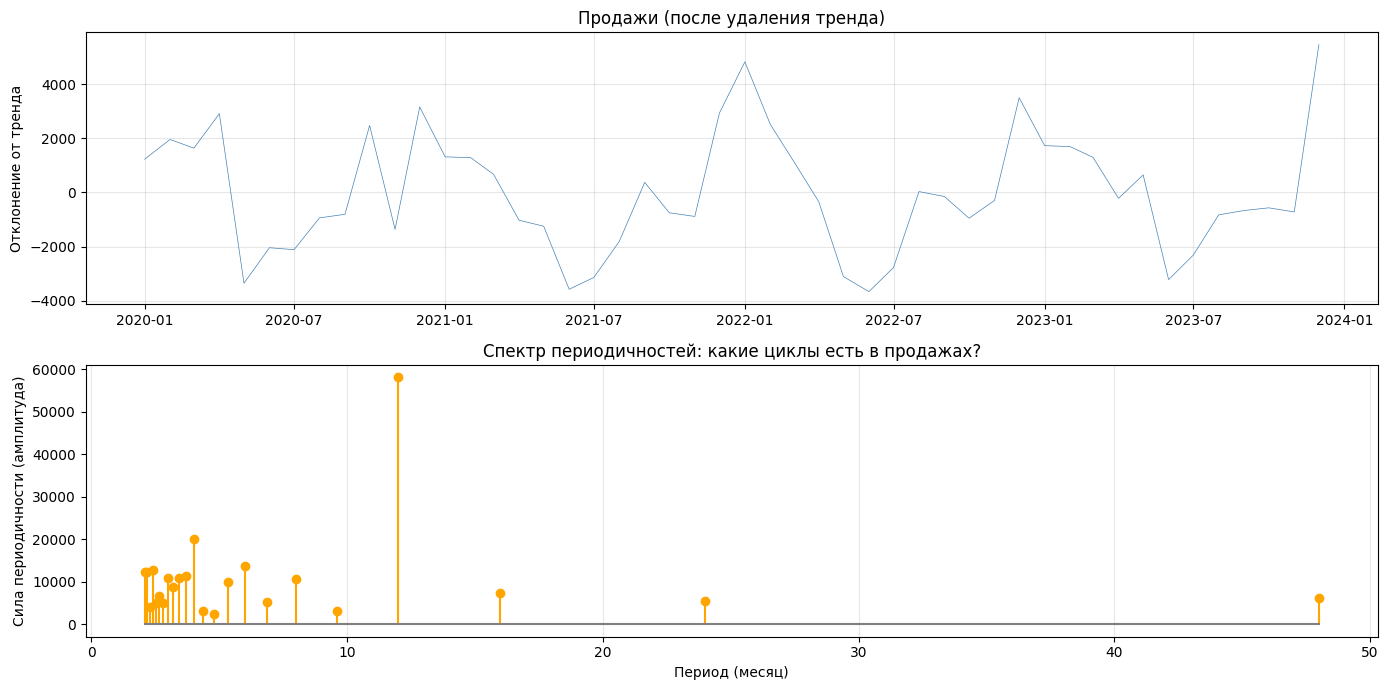

In [51]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Исходный ряд (после детрендинга)
axs[0].plot(df.index, sales_detrended, color='steelblue', linewidth=0.5)
axs[0].set_title('Продажи (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Спектр по периодам (удобнее для бизнеса)
mask = (periods >= 2) & (periods <= 700)
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяц)')
axs[1].set_ylabel('Сила периодичности (амплитуда)')
axs[1].set_title('Спектр периодичностей: какие циклы есть в продажах?')
axs[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Спектральный Фурье-анализ выявил доминирующий цикл длительностью около 12 периодов, что соответствует годовой сезонности. 
# Дополнительно обнаружены слабые пики в районе 6 периодов, что может свидетельствовать о наличии полугодовых колебаний. 
# Но явно 12 месяцев

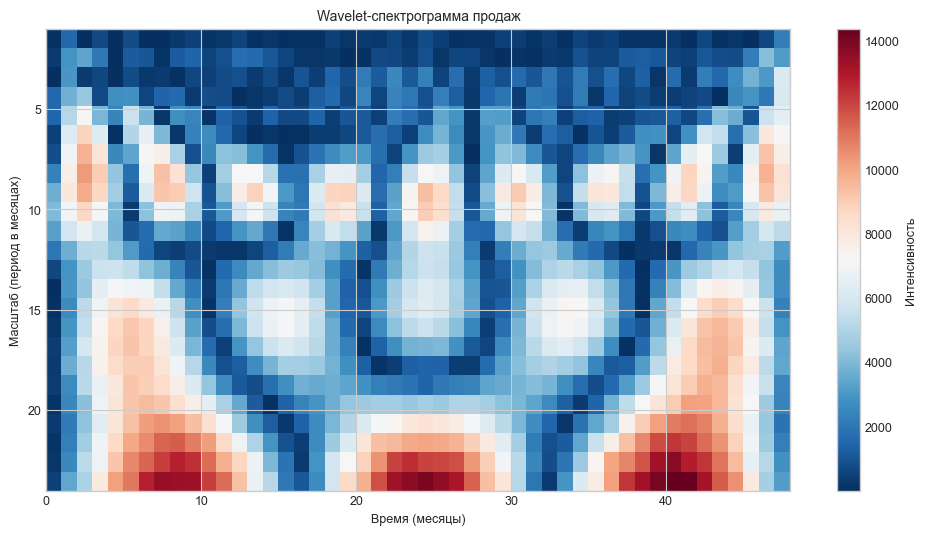

In [61]:
signal = df['SalesAmount'].values

# Масштабы (до 24 месяцев)
scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(signal, scales, 'morl')

plt.figure(figsize=(12,6))

plt.imshow(np.abs(coefficients),
           extent=[0, len(signal), scales.max(), scales.min()],
           aspect='auto',
           cmap='RdBu_r')

plt.colorbar(label="Интенсивность")
plt.ylabel("Масштаб (период в месяцах)")
plt.xlabel("Время (месяцы)")
plt.title("Wavelet-спектрограмма продаж")

plt.show()

In [62]:
# В ряду присутствует устойчивая годовая сезонность (период 12 месяцев), которая сохраняется на всем интервале наблюдений
# Амплитуда сезонных колебаний увеличивается во времени. Это свидетельствует о возможном усилении сезонного эффекта в последние годы
# Помимо годовой сезонноси наблюдаются менее выраженные полугодовые колебания, вероятно связанные с промежуточными акциями или сезонными всплесками спроса

Был проанализирован временной ряд розничных продаж. Анализ показал наличие восходящего тренда и выраженной сезонности с периодом около 12 месяцев, а также полугодовую сезонность.

Были применены различные методы разложения и анализа:

**Аддитивная и мультипликативная декомпозиции позволяют разделить ряд на тренд, сезонность и остатки**
- Плюс — простота и наглядность
- Минус — предполагают фиксированную структуру сезонности

**STL-декомпозиция также выделяет тренд и сезонность, но делает это более гибко**
- Плюс — может учитывать изменение сезонности во времени
- Минус — более сложная настройка и интерпретация

**Спектральный анализ (FFT) позволяет определить, какие циклы присутствуют в данных**
- Плюс — хорошо выявляет доминирующие периоды
-  Минус — не показывает, в какие моменты времени эти циклы усиливаются или ослабевают

**Вейвлет-анализ показывает не только наличие циклов, но и их изменение во времени**
- Плюс — подходит для нестационарных рядов
- Минус — сложнее в интерпретации

В целом, для наших учебных данных для выявления сезонности и тренда достаточно просто посмотреть на самый первый график. Данные хорошо читаются и легко интерпретируются с 
точки зрения жизненной логики и бизнеса.
Все наши методы подтвердили наличие годового цикла

# Построение прогнозных моделей

На основе результатов EDA и декомпозиции подобрать параметры моделей ARIMA и SARIMAX.

Обучить модели на тренировочной выборке, выполнить прогноз на максимально возможный горизонт с сохранением приемлемого качества.

In [8]:
# Для наглядности начну заново

In [11]:
df = pd.read_csv('retail_sales_mock_data.csv')
# Преобразуем дату
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [21]:
y = df['SalesAmount']
x = df[['Promotion', 'HolidayMonth']]

In [ ]:
# Разбивка на трейн и тест. Данные отсортированы, поэтому все в порядке
train = y[:36]
test = y[36:]

exog_train = x[:36]
exog_test = x[36:]

In [ ]:
result = adfuller(train)
print("ADF:", result[0])
print("p-value:", result[1])

ADF: -3.769957098571164
p-value: 0.003230091349138584


In [66]:
# Значит ряд стационарен и d=0

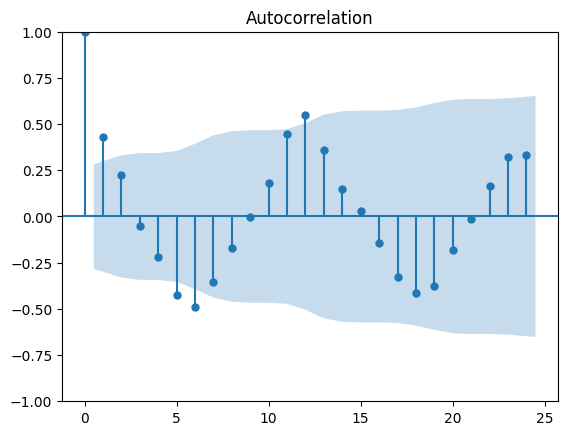

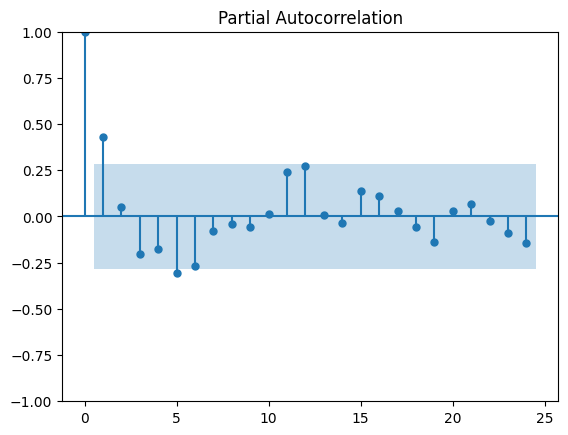

In [72]:
plot_acf(y, lags=24)
plot_pacf(y, lags=24)
plt.show()

In [ ]:
# Тренд у нас совсем небольшой, поэтому d=0
# Судя по графикам
# p = 2
# q = 2

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -317.771
Date:                Fri, 27 Feb 2026   AIC                            647.542
Time:                        17:36:05   BIC                            657.043
Sample:                    01-01-2020   HQIC                           650.859
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.144e+04     70.966    161.158      0.000    1.13e+04    1.16e+04
ar.L1          1.5996      0.190      8.433      0.000       1.228       1.971
ar.L2         -0.8314      0.158     -5.272      0.0

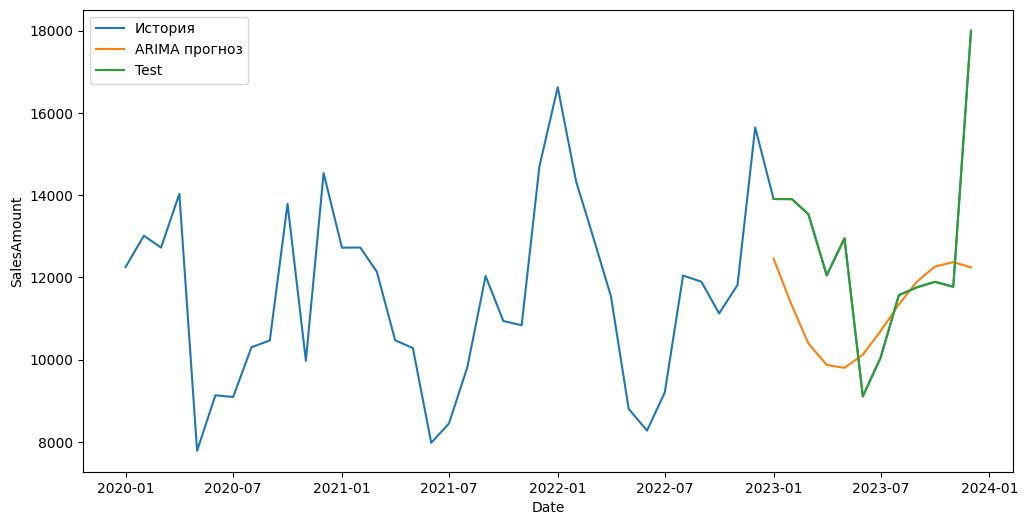

In [ ]:
model_arima = ARIMA(train, order=(2,0,2)).fit()
print(model_arima.summary())

forecast_arima = model_arima.forecast(steps=12)

plt.figure(figsize=(12,6))
sns.lineplot(data=y, label='История')
sns.lineplot(data=forecast_arima, label='ARIMA прогноз')
sns.lineplot(data=test, label="Test")
plt.legend()
plt.show()

In [ ]:
# С лучшими параметрами получился такой результат. Но, если попробовать поподбирать, можно найти варианты и лучше

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                ARIMA(12, 0, 1)   Log Likelihood                -315.513
Date:                Fri, 27 Feb 2026   AIC                            661.026
Time:                        17:30:20   BIC                            684.779
Sample:                    01-01-2020   HQIC                           669.317
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    221.822     51.897      0.000    1.11e+04    1.19e+04
ar.L1         -0.0465      0.337     -0.138      0.890      -0.707       0.614
ar.L2          0.0275      0.129      0.214      0.8

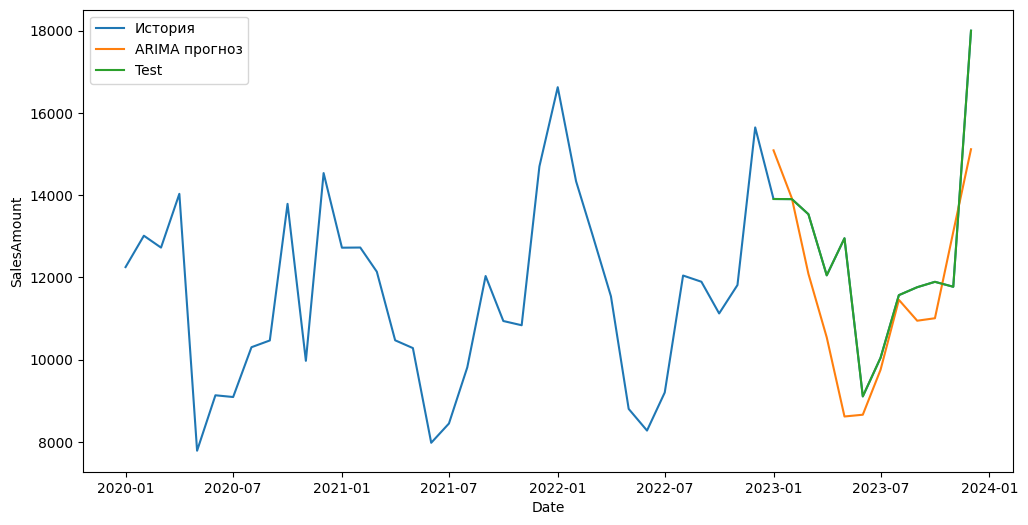

In [ ]:
model_arima_dop = ARIMA(train, order=(12,0,1)).fit()
print(model_arima_dop.summary())

forecast_arima = model_arima_dop.forecast(steps=12)

plt.figure(figsize=(12,6))
sns.lineplot(data=y, label='История')
sns.lineplot(data=forecast_arima, label='ARIMA прогноз')
sns.lineplot(data=test, label="Test")
plt.legend()
plt.show()

In [ ]:
# Несмотря на то, что модель (12,0,1) визуально лучше подгоняет исторические данные, 
# она использует слишком большое количество параметров при малом объеме выборки (36), 
# что может привести к переобучению. Более компактная модель (2,0,2) является статистически более устойчивой

In [94]:
model_sarima = SARIMAX(
    train,
    order=(2,0,2),
    seasonal_order=(1,0,1,12)
).fit()

print(model_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                          SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 12)   Log Likelihood                -322.549
Date:                              Fri, 27 Feb 2026   AIC                            659.098
Time:                                      17:31:55   BIC                            670.183
Sample:                                  01-01-2020   HQIC                           662.967
                                       - 12-01-2022                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1120      0.523      0.214      0.830      -0.913       1.137
ar.L2          0.88

                                      SARIMAX Results                                      
Dep. Variable:                         SalesAmount   No. Observations:                   36
Model:             SARIMAX(2, 0, 2)x(1, 1, [], 12)   Log Likelihood                -209.653
Date:                             Fri, 27 Feb 2026   AIC                            431.306
Time:                                     17:38:11   BIC                            438.374
Sample:                                 01-01-2020   HQIC                           433.181
                                      - 12-01-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0333      0.882     -0.038      0.970      -1.761       1.695
ar.L2         -0.3042      

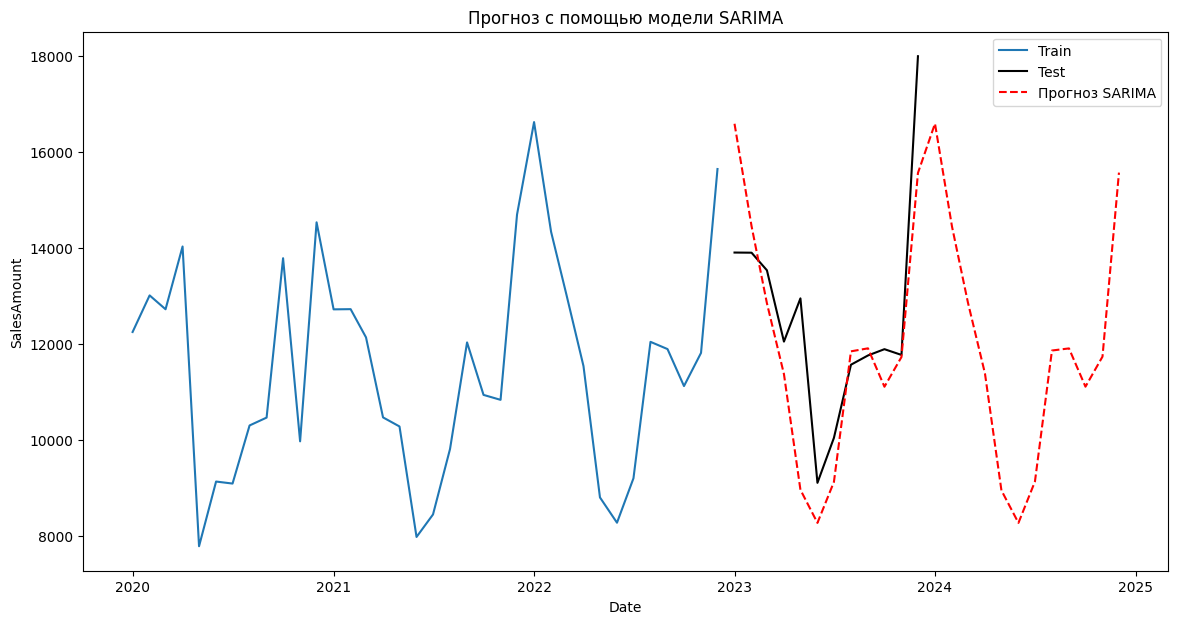

In [106]:
model_sarima = SARIMAX(train, order=(2,0,2), seasonal_order=(1, 1, 0, 12)).fit()
print(model_sarima.summary())

# Прогноз на длину теста (12 месяцев) + 12 месяцев далее для примера
forecast_sarima = model_sarima.predict(start=len(train), end=len(y)+11, typ='levels')

# График
plt.figure(figsize=(14, 7))
sns.lineplot(data=train, label='Train')
sns.lineplot(data=test, label='Test', color='black')
sns.lineplot(data=forecast_sarima, label='Прогноз SARIMA', linestyle='--', color='red')
plt.title('Прогноз с помощью модели SARIMA')
plt.legend()
plt.show()

In [ ]:
# Визуально Сарима модель выглядит сильно лучше, чем Арима. 
# Учитывать сезонность в наших данных явно необходимо, что подтверждается всеми пунктами текущей ЛР

# Оценка качества моделей


- Рассчитать метрики качества прогноза:
  - среднеквадратичная ошибка (MSE);
  - коэффициент детерминации (R²).
- Провести сравнение моделей по информационным критериям:

  - Akaike Information Criterion (AIC);
  - Bayesian Information Criterion (BIC).
- Провести анализ остатков моделей (нормальность, автокоррелированность, гомоскедастичность)


Представить результаты в табличной и графической форме, сделать вывод о предпочтительной модели.

In [109]:
# Для ARIMA
mse_arima = mean_squared_error(test, forecast_arima)
r2_arima = r2_score(test, forecast_arima)

# Для SARIMA
mse_sarima = mean_squared_error(test, forecast_sarima[-len(test):])
r2_sarima = r2_score(test, forecast_sarima[-len(test):])

In [108]:
# Информационные критерии AIC и BIC
aic_arima = model_arima.aic
bic_arima = model_arima.bic

aic_sarima = model_sarima.aic
bic_sarima = model_sarima.bic

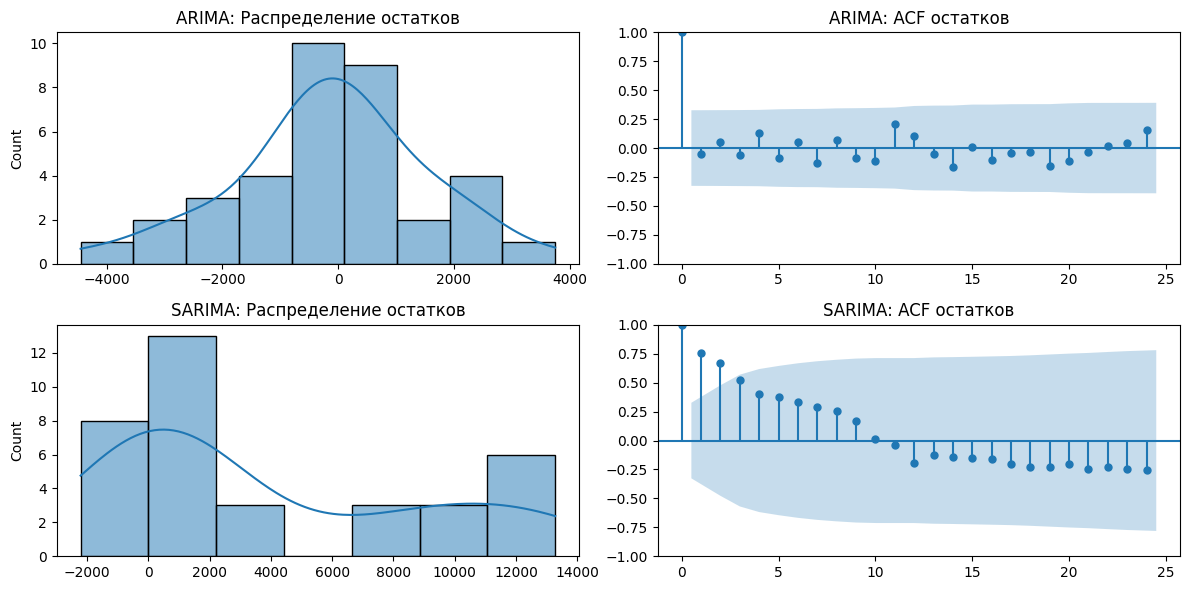

In [110]:
# Остатки ARIMA
resid_arima = model_arima.resid

# Остатки SARIMA
resid_sarima = model_sarima.resid[-len(train):]

# Графики остатков
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.histplot(resid_arima, kde=True)
plt.title('ARIMA: Распределение остатков')

plt.subplot(2,2,2)
sm.graphics.tsa.plot_acf(resid_arima, lags=24, ax=plt.gca())
plt.title('ARIMA: ACF остатков')

plt.subplot(2,2,3)
sns.histplot(resid_sarima, kde=True)
plt.title('SARIMA: Распределение остатков')

plt.subplot(2,2,4)
sm.graphics.tsa.plot_acf(resid_sarima, lags=24, ax=plt.gca())
plt.title('SARIMA: ACF остатков')

plt.tight_layout()
plt.show()

In [111]:
results = pd.DataFrame({
    'Модель': ['ARIMA(2,0,2)', 'SARIMA(2,0,2)(1,1,1,12)'],
    'MSE': [mse_arima, mse_sarima],
    'R2': [r2_arima, r2_sarima],
    'AIC': [aic_arima, aic_sarima],
    'BIC': [bic_arima, bic_sarima]
})

display(results)

,Модель,MSE,R2,AIC,BIC
0,"ARIMA(2,0,2)",5.706711e+06,-0.233922,647.542385,657.043498
1,"SARIMA(2,0,2)(1,1,1,12)",2.714118e+06,0.413145,431.305821,438.374144


In [ ]:
# Выводы по моделям

# ARIMA(2,0,2) плохо прогнозирует: высокая ошибка (MSE), отрицательный R2 — модель хуже, чем просто среднее.
# SARIMA(2,0,2)(1,1,1,12) прогнозирует лучше: MSE меньше, R2 положительный, AIC и BIC ниже — модель учитывает сезонность и точнее.
# Предпочтительная модель для этого ряда — SARIMA, так как она точнее и остатки более случайные.

# Документирование и интерпретация

Каждый этап решения должен быть снабжен поясняющими комментариями в коде.
По завершении каждого из пяти основных пунктов сформулировать аналитические выводы

In [ ]:
# Я увидел только 3 основных этапа...

# Итоговый вывод по всей работе
Был проведен анализ временного ряда розничных продаж, который показал восходящий тренд и выраженную сезонность с периодом около 12 месяцев. Различные методы разложения (аддитивная, мультипликативная, STL, спектральный и вейвлет-анализ) подтвердили наличие годового цикла и показали, что данные хорошо интерпретируются с точки зрения бизнеса. Для прогнозирования были построены модели ARIMA и SARIMA: ARIMA показала низкую точность, тогда как SARIMA(2,0,2)(1,1,1,12) продемонстрировала более точный прогноз с меньшей MSE, положительным R² и лучшими информационными критериями. В целом, SARIMA является предпочтительной моделью для прогноза этого ряда, учитывая сезонность и тренд.